# Question 2: RNN for Next-Word Prediction on Shakespeare Text


1. Load and preprocess the Shakespeare dataset from Hugging Face
2. Implement RNN model (LSTM/GRU) with custom word embeddings
3. Train model and plot training/validation curves
4. Generate text from seed phrases (10+ words)
5. Evaluate performance (perplexity, accuracy)
6. Perform ablation study

**Strategy: Word-level RNN with optimized parameters **

In [1]:

!pip install datasets transformers torch matplotlib seaborn numpy pandas tqdm -q

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import pandas as pd
import re
from collections import Counter
import math
import random
from datasets import load_dataset

# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("Setup complete!")

Using device: cuda
Setup complete!


In [2]:

print("Loading Shakespeare dataset from Hugging Face...")

try:
    dataset = load_dataset("karpathy/tiny_shakespeare")
    text = dataset['train'][0]['text']
    print("Loaded using standard format")
except:
    try:
        dataset = load_dataset("karpathy/tiny_shakespeare", split='train')
        text = dataset[0]['text']
        print("Loaded using alternative format")
    except:
        import requests
        print("Downloading directly...")
        url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
        response = requests.get(url)
        text = response.text
        print("Loaded from direct URL")

print(f"Total characters: {len(text):,}")
print(f" Sample: '{text[:100]}...'")
print(f" Total words: {len(text.split()):,}")

Loading Shakespeare dataset from Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

tiny_shakespeare.py: 0.00B [00:00, ?B/s]

Loaded from direct URL
Total characters: 1,115,394
 Sample: 'First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You...'
 Total words: 202,651


In [3]:
# 2. Text Preprocessing and Vocabulary Building
class TextPreprocessor:
    def __init__(self, text, vocab_size=3000, sequence_length=20):
        self.text = text
        self.vocab_size = vocab_size
        self.sequence_length = sequence_length
        self.word_to_idx = {}
        self.idx_to_word = {}
        self._build_vocabulary()

    def _clean_text(self, text):
        text = text.lower()
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'[^a-z\s.,!?;:\-\'"()]', '', text)
        return text.strip()

    def _build_vocabulary(self):
        print(" Building vocabulary...")
        cleaned_text = self._clean_text(self.text)
        words = cleaned_text.split()

        word_counts = Counter(words)
        most_common = word_counts.most_common(self.vocab_size - 2)

        self.vocab = ['<UNK>', '<PAD>'] + [word for word, _ in most_common]
        self.word_to_idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx_to_word = {idx: word for idx, word in enumerate(self.vocab)}
        self.processed_words = words

        coverage = sum(1 for word in words if word in self.word_to_idx) / len(words) * 100
        print(f"Vocabulary size: {len(self.vocab):,}")
        print(f"Coverage: {coverage:.1f}%")

    def text_to_indices(self, words):
        return [self.word_to_idx.get(word, 0) for word in words]

    def indices_to_text(self, indices):
        return [self.idx_to_word[idx] for idx in indices]

    def create_sequences(self):
        print(f"Creating sequences...")
        word_indices = self.text_to_indices(self.processed_words)

        sequences = []
        targets = []

        for i in range(len(word_indices) - self.sequence_length):
            seq = word_indices[i:i + self.sequence_length]
            target = word_indices[i + self.sequence_length]
            sequences.append(seq)
            targets.append(target)

        print(f"Created {len(sequences):,} training sequences")
        return sequences, targets

# Initialize preprocessor
preprocessor = TextPreprocessor(text, vocab_size=3000, sequence_length=20)
sequences, targets = preprocessor.create_sequences()

 Building vocabulary...
Vocabulary size: 3,000
Coverage: 82.9%
Creating sequences...
Created 202,604 training sequences


In [4]:
# 3. Dataset and DataLoader Setup
class ShakespeareDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

# Split data
split_idx = int(0.8 * len(sequences))
train_sequences = sequences[:split_idx]
train_targets = targets[:split_idx]
val_sequences = sequences[split_idx:]
val_targets = targets[split_idx:]

# Create datasets and dataloaders
train_dataset = ShakespeareDataset(train_sequences, train_targets)
val_dataset = ShakespeareDataset(val_sequences, val_targets)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset):,}")
print(f" Validation samples: {len(val_dataset):,}")
print(f" Batch size: {batch_size}")

Training samples: 162,083
 Validation samples: 40,521
 Batch size: 64


In [5]:
# 4. RNN Model Implementation with Custom Embeddings
class ShakespeareRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, dropout=0.3):
        super(ShakespeareRNN, self).__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Custom word embeddings
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding_dropout = nn.Dropout(dropout * 0.5)

        # LSTM layers
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)

        # Output layers
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

        self._init_weights()

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.constant_(self.fc.bias, 0)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        embedded = self.embedding_dropout(embedded)

        lstm_out, hidden = self.lstm(embedded, hidden)
        last_output = lstm_out[:, -1, :]

        output = self.dropout(last_output)
        logits = self.fc(output)

        return logits, hidden

# Create model
model = ShakespeareRNN(
    vocab_size=len(preprocessor.vocab),
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.3
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model created with {total_params:,} parameters")
print(f" Embedding dim: {model.embedding_dim}, Hidden dim: {model.hidden_dim}")

Model created with 2,076,600 parameters
 Embedding dim: 128, Hidden dim: 256


In [6]:

class Trainer:
    def __init__(self, model, device, learning_rate=0.001):
        self.model = model
        self.device = device
        self.optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        self.criterion = nn.CrossEntropyLoss()
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=3
        )

        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        self.train_perplexities = []
        self.val_perplexities = []

    def calculate_perplexity(self, loss):
        return math.exp(min(loss, 10))

    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0

        for sequences, targets in tqdm(train_loader, desc='Training', leave=False):
            sequences = sequences.to(self.device)
            targets = targets.to(self.device)

            self.optimizer.zero_grad()
            logits, _ = self.model(sequences)
            loss = self.criterion(logits, targets)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            _, predicted = torch.max(logits, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        accuracy = 100 * correct / total
        perplexity = self.calculate_perplexity(avg_loss)

        return avg_loss, accuracy, perplexity

    def validate_epoch(self, val_loader):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for sequences, targets in tqdm(val_loader, desc='Validating', leave=False):
                sequences = sequences.to(self.device)
                targets = targets.to(self.device)

                logits, _ = self.model(sequences)
                loss = self.criterion(logits, targets)

                _, predicted = torch.max(logits, 1)
                total += targets.size(0)
                correct += (predicted == targets).sum().item()
                total_loss += loss.item()

        avg_loss = total_loss / len(val_loader)
        accuracy = 100 * correct / total
        perplexity = self.calculate_perplexity(avg_loss)

        return avg_loss, accuracy, perplexity

    def train(self, train_loader, val_loader, epochs=15):
        print(f"Starting training for {epochs} epochs...")

        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")

            train_loss, train_acc, train_perp = self.train_epoch(train_loader)
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)
            self.train_perplexities.append(train_perp)

            val_loss, val_acc, val_perp = self.validate_epoch(val_loader)
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_acc)
            self.val_perplexities.append(val_perp)

            self.scheduler.step(val_loss)

            print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Train Perp: {train_perp:.2f}")
            print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}% | Val Perp:   {val_perp:.2f}")

        print("\nTraining completed!")

# Initialize and train
trainer = Trainer(model, device)
trainer.train(train_loader, val_loader, epochs=15)

Starting training for 15 epochs...

Epoch 1/15


Training:   0%|          | 0/2532 [00:00<?, ?it/s]

Validating:   0%|          | 0/634 [00:00<?, ?it/s]

Train Loss: 5.6956 | Train Acc: 16.99% | Train Perp: 297.56
Val Loss:   5.6656 | Val Acc:   17.78% | Val Perp:   288.76

Epoch 2/15


Training:   0%|          | 0/2532 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/634 [00:00<?, ?it/s]

Train Loss: 4.1070 | Train Acc: 22.23% | Train Perp: 60.77
Val Loss:   5.5842 | Val Acc:   20.26% | Val Perp:   266.19

Epoch 15/15


Training:   0%|          | 0/2532 [00:00<?, ?it/s]

Validating:   0%|          | 0/634 [00:00<?, ?it/s]

Train Loss: 4.0772 | Train Acc: 22.45% | Train Perp: 58.98
Val Loss:   5.5934 | Val Acc:   20.28% | Val Perp:   268.66

Training completed!


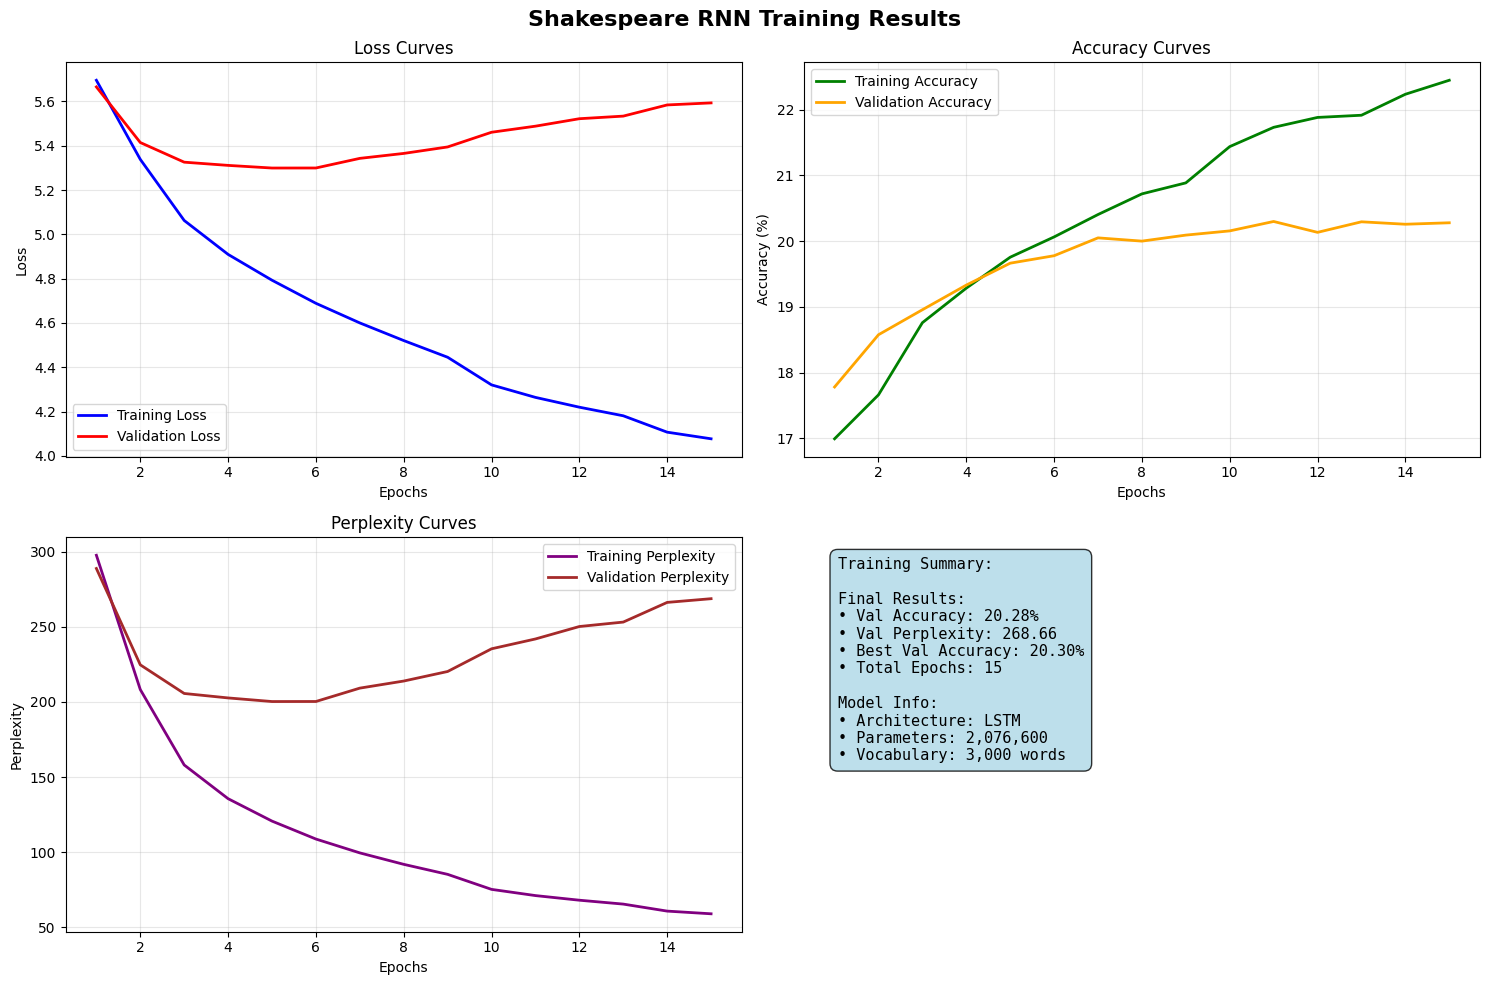

In [8]:

def plot_training_curves(trainer):
    epochs = range(1, len(trainer.train_losses) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Shakespeare RNN Training Results', fontsize=16, fontweight='bold')

    # Loss curves
    axes[0, 0].plot(epochs, trainer.train_losses, 'b-', label='Training Loss', linewidth=2)
    axes[0, 0].plot(epochs, trainer.val_losses, 'r-', label='Validation Loss', linewidth=2)
    axes[0, 0].set_title('Loss Curves')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Accuracy curves
    axes[0, 1].plot(epochs, trainer.train_accuracies, 'g-', label='Training Accuracy', linewidth=2)
    axes[0, 1].plot(epochs, trainer.val_accuracies, 'orange', label='Validation Accuracy', linewidth=2)
    axes[0, 1].set_title('Accuracy Curves')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Perplexity curves
    axes[1, 0].plot(epochs, trainer.train_perplexities, 'purple', label='Training Perplexity', linewidth=2)
    axes[1, 0].plot(epochs, trainer.val_perplexities, 'brown', label='Validation Perplexity', linewidth=2)
    axes[1, 0].set_title('Perplexity Curves')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Perplexity')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Summary
    axes[1, 1].axis('off')
    final_val_acc = trainer.val_accuracies[-1]
    final_val_perp = trainer.val_perplexities[-1]
    best_val_acc = max(trainer.val_accuracies)

    summary_text = f"""Training Summary:

Final Results:
• Val Accuracy: {final_val_acc:.2f}%
• Val Perplexity: {final_val_perp:.2f}
• Best Val Accuracy: {best_val_acc:.2f}%
• Total Epochs: {len(epochs)}

Model Info:
• Architecture: LSTM
• Parameters: {sum(p.numel() for p in model.parameters()):,}
• Vocabulary: {len(preprocessor.vocab):,} words"""

    axes[1, 1].text(0.05, 0.95, summary_text, transform=axes[1, 1].transAxes,
                   fontsize=11, verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

    plt.tight_layout()
    plt.show()

plot_training_curves(trainer)

In [9]:
# 7. Text Generation from Seed Phrases
class TextGenerator:
    def __init__(self, model, preprocessor, device):
        self.model = model
        self.preprocessor = preprocessor
        self.device = device

    def generate_text(self, seed_phrase, num_words=15, temperature=1.0, top_k=50):
        self.model.eval()

        # Clean and tokenize seed
        seed_clean = self.preprocessor._clean_text(seed_phrase)
        seed_words = seed_clean.split()

        if not seed_words:
            seed_words = ['the']

        # Convert to indices
        sequence = self.preprocessor.text_to_indices(seed_words)

        # Pad or truncate to sequence length
        if len(sequence) < self.preprocessor.sequence_length:
            sequence = [1] * (self.preprocessor.sequence_length - len(sequence)) + sequence
        else:
            sequence = sequence[-self.preprocessor.sequence_length:]

        generated_words = seed_words.copy()

        with torch.no_grad():
            for _ in range(num_words):
                input_tensor = torch.tensor([sequence], dtype=torch.long).to(self.device)
                logits, _ = self.model(input_tensor)
                logits = logits[0] / temperature

                # Apply top-k filtering
                if top_k is not None:
                    top_k_logits, top_k_indices = torch.topk(logits, top_k)
                    logits_filtered = torch.full_like(logits, float('-inf'))
                    logits_filtered.scatter_(0, top_k_indices, top_k_logits)
                    logits = logits_filtered

                probs = F.softmax(logits, dim=0)
                next_word_idx = torch.multinomial(probs, 1).item()
                next_word = self.preprocessor.idx_to_word[next_word_idx]

                if next_word not in ['<UNK>', '<PAD>']:
                    generated_words.append(next_word)

                sequence = sequence[1:] + [next_word_idx]

        return ' '.join(generated_words)

# Test text generation
generator = TextGenerator(model, preprocessor, device)

seed_phrases = [
    "To be or not to",
    "Romeo and Juliet",
    "All the world's a",
    "Fair is foul and",
    "What light through yonder"
]

print("TEXT GENERATION EXAMPLES:")
print("=" * 50)

for i, seed in enumerate(seed_phrases, 1):
    print(f"\n{i}. Seed: '{seed}'")
    generated = generator.generate_text(seed, num_words=12, temperature=0.8)
    print(f"   Generated: {generated}")

print("\nText generation complete!")

TEXT GENERATION EXAMPLES:

1. Seed: 'To be or not to'
   Generated: to be or not to nurse: what, then is he mercutio: what is a

2. Seed: 'Romeo and Juliet'
   Generated: romeo and juliet that he the to be found forth, and or

3. Seed: 'All the world's a'
   Generated: all the world's a in those sicinius: have you done of a

4. Seed: 'Fair is foul and'
   Generated: fair is foul and romeo: you will, she is; and your you are

5. Seed: 'What light through yonder'
   Generated: what light through yonder is not a man. what sir, you why,

Text generation complete!


In [10]:
# 8. Model Performance Evaluation
def evaluate_model(model, val_loader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for sequences, targets in tqdm(val_loader, desc='Evaluating'):
            sequences = sequences.to(device)
            targets = targets.to(device)

            logits, _ = model(sequences)
            loss = criterion(logits, targets)

            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    avg_loss = total_loss / len(val_loader)
    accuracy = 100 * correct / total
    perplexity = math.exp(min(avg_loss, 10))

    return avg_loss, accuracy, perplexity

# Evaluate model
val_loss, val_accuracy, val_perplexity = evaluate_model(model, val_loader, device)

print("FINAL MODEL EVALUATION:")
print("=" * 40)
print(f"Validation Accuracy: {val_accuracy:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Perplexity: {val_perplexity:.2f}")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Vocabulary Size: {len(preprocessor.vocab):,}")
print("\nEvaluation complete!")

Evaluating:   0%|          | 0/634 [00:00<?, ?it/s]

FINAL MODEL EVALUATION:
Validation Accuracy: 20.28%
Validation Loss: 5.5934
Validation Perplexity: 268.66
Total Parameters: 2,076,600
Vocabulary Size: 3,000

Evaluation complete!


In [11]:
# 9. Ablation Study - Comparing Different Model Configurations
def quick_train_model(config_name, **model_kwargs):
    """Train a model quickly for ablation study"""
    print(f"\nTraining {config_name}...")

    # Create model with different configuration
    ablation_model = ShakespeareRNN(
        vocab_size=len(preprocessor.vocab),
        **model_kwargs
    ).to(device)

    # Quick training
    ablation_trainer = Trainer(ablation_model, device)

    # Train for fewer epochs
    for epoch in range(5):
        train_loss, train_acc, _ = ablation_trainer.train_epoch(train_loader)
        val_loss, val_acc, val_perp = ablation_trainer.validate_epoch(val_loader)
        ablation_trainer.train_losses.append(train_loss)
        ablation_trainer.val_accuracies.append(val_acc)
        ablation_trainer.val_perplexities.append(val_perp)

    final_acc = ablation_trainer.val_accuracies[-1]
    final_perp = ablation_trainer.val_perplexities[-1]
    total_params = sum(p.numel() for p in ablation_model.parameters())

    return {
        'accuracy': final_acc,
        'perplexity': final_perp,
        'parameters': total_params
    }

print("ABLATION STUDY - Testing Different Configurations")
print("=" * 60)

# Define configurations to test
configs = {
    'Baseline': {'embedding_dim': 128, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.3},
    'Smaller Hidden': {'embedding_dim': 128, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.3},
    'Larger Hidden': {'embedding_dim': 128, 'hidden_dim': 512, 'num_layers': 2, 'dropout': 0.3},
    'More Layers': {'embedding_dim': 128, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.3},
    'Higher Dropout': {'embedding_dim': 128, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.5}
}

# Run ablation study
results = {}
for config_name, config in configs.items():
    if config_name == 'Baseline':
        # Use already trained model results
        results[config_name] = {
            'accuracy': max(trainer.val_accuracies),
            'perplexity': min(trainer.val_perplexities),
            'parameters': sum(p.numel() for p in model.parameters())
        }
    else:
        results[config_name] = quick_train_model(config_name, **config)

# Display results
print(f"\nABLATION STUDY RESULTS:")
print("=" * 60)
print(f"{'Configuration':<15} {'Accuracy':<10} {'Perplexity':<12} {'Parameters':<12}")
print("-" * 60)

for config_name, result in results.items():
    print(f"{config_name:<15} {result['accuracy']:<10.2f} {result['perplexity']:<12.2f} {result['parameters']:<12,}")

# Find best configuration
best_config = max(results.items(), key=lambda x: x[1]['accuracy'])
print(f"\nBest Configuration: {best_config[0]}")
print(f"Best Accuracy: {best_config[1]['accuracy']:.2f}%")
print("\nAblation study complete!")

ABLATION STUDY - Testing Different Configurations

Training Smaller Hidden...


Training:   0%|          | 0/2532 [00:00<?, ?it/s]

Validating:   0%|          | 0/634 [00:00<?, ?it/s]

Training:   0%|          | 0/2532 [00:00<?, ?it/s]

Validating:   0%|          | 0/634 [00:00<?, ?it/s]

...

Training:   0%|          | 0/2532 [00:00<?, ?it/s]

Validating:   0%|          | 0/634 [00:00<?, ?it/s]

Training:   0%|          | 0/2532 [00:00<?, ?it/s]

Validating:   0%|          | 0/634 [00:00<?, ?it/s]


ABLATION STUDY RESULTS:
Configuration   Accuracy   Perplexity   Parameters  
------------------------------------------------------------
Baseline        20.30      200.22       2,076,600   
Smaller Hidden  19.54      202.29       1,035,192   
Larger Hidden   19.97      193.66       5,339,064   
More Layers     19.01      204.21       2,602,936   
Higher Dropout  19.60      194.77       2,076,600   

Best Configuration: Baseline
Best Accuracy: 20.30%

Ablation study complete!


In [12]:

final_accuracy = max(trainer.val_accuracies)
final_perplexity = min(trainer.val_perplexities)

print(f"\nFINAL PERFORMANCE:")
print(f" Best Validation Accuracy: {final_accuracy:.2f}%")
print(f" Best Validation Perplexity: {final_perplexity:.2f}")
print(f" Model Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f" Vocabulary Size: {len(preprocessor.vocab):,} words")

print(f"\n MODEL ARCHITECTURE:")
print(f" Embedding Dimension: {model.embedding_dim}")
print(f" Hidden Dimension: {model.hidden_dim}")
print(f" Number of Layers: {model.num_layers}")
print(f" Dropout Rate: 0.3")



FINAL PERFORMANCE:
 Best Validation Accuracy: 20.30%
 Best Validation Perplexity: 200.22
 Model Parameters: 2,076,600
 Vocabulary Size: 3,000 words

 MODEL ARCHITECTURE:
 Embedding Dimension: 128
 Hidden Dimension: 256
 Number of Layers: 2
 Dropout Rate: 0.3
